In [1]:
import pandas as pd
import numpy as np
import sklearn
import xgboost
import shap
import streamlit

print("All libraries loaded successfully!")


All libraries loaded successfully!


In [2]:
import pandas as pd

# Load dataset
data = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Convert TotalCharges to numeric (handle blanks)
data["TotalCharges"] = pd.to_numeric(data["TotalCharges"], errors="coerce")
data = data.dropna()

# Drop customerID
data = data.drop("customerID", axis=1)

print("Data shape:", data.shape)
print(data.head())


Data shape: (7032, 20)
   gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  Female              0     Yes         No       1           No   
1    Male              0      No         No      34          Yes   
2    Male              0      No         No       2          Yes   
3    Male              0      No         No      45           No   
4  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity OnlineBackup  \
0  No phone service             DSL             No          Yes   
1                No             DSL            Yes           No   
2                No             DSL            Yes          Yes   
3  No phone service             DSL            Yes           No   
4                No     Fiber optic             No           No   

  DeviceProtection TechSupport StreamingTV StreamingMovies        Contract  \
0               No          No          No              No  Month-to-month   
1        

In [3]:
# One-hot encode categorical variables
data = pd.get_dummies(data, drop_first=True)

# Features and target
X = data.drop("Churn_Yes", axis=1)
y = data["Churn_Yes"]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, recall_score, f1_score

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train model
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

# Predictions
y_pred = log_reg.predict(X_test_scaled)

# Metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))


Accuracy: 0.8038379530916845
Recall: 0.5748663101604278
F1 Score: 0.6090651558073654


In [12]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, recall_score, f1_score

# 1. Define the model
xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss",
    scale_pos_weight=len(y_train[y_train==0]) / len(y_train[y_train==1])  # handle imbalance
)

# 2. Fit the model
xgb_model.fit(X_train, y_train)

# 3. Predict
y_pred_xgb = xgb_model.predict(X_test)

# 4. Evaluate
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("XGBoost Recall:", recall_score(y_test, y_pred_xgb))
print("XGBoost F1 Score:", f1_score(y_test, y_pred_xgb))
xgb_model.save_model("xgb_churn.json")



XGBoost Accuracy: 0.7448471926083866
XGBoost Recall: 0.767379679144385
XGBoost F1 Score: 0.6152197213290461


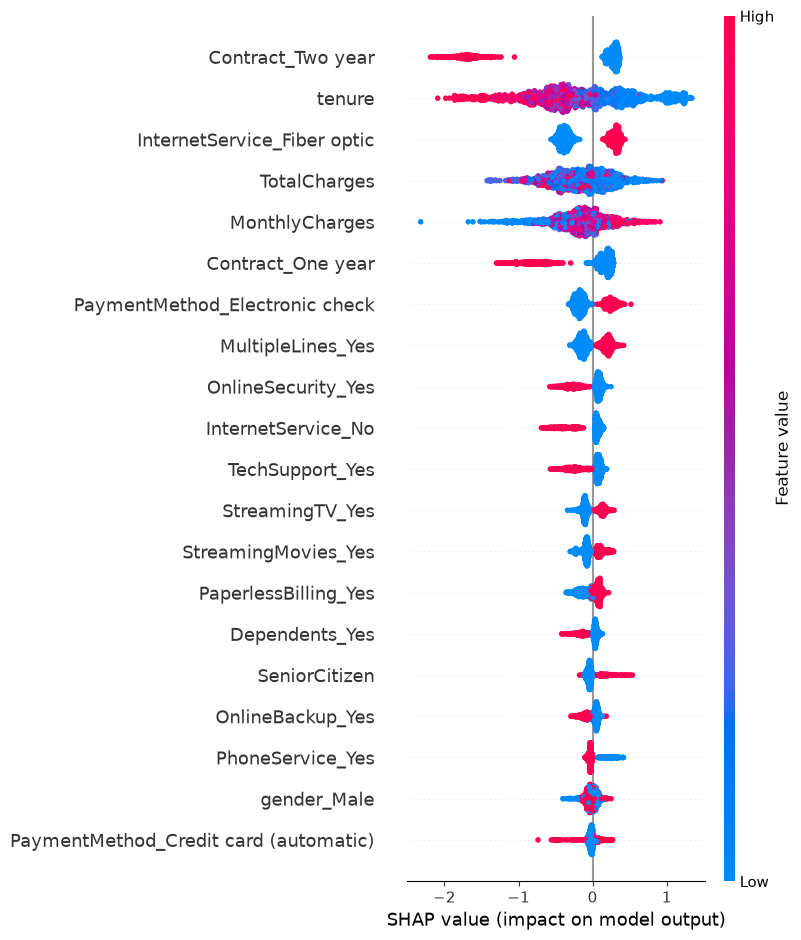

In [10]:
import shap

# Create explainer
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

# Summary plot (global feature importance)
shap.summary_plot(shap_values, X_test)

# Force plot for a single customer (local explanation)
shap.initjs()
customer_index = 0  # pick any row from X_test
shap.force_plot(explainer.expected_value, shap_values[customer_index], X_test.iloc[customer_index])


In [2]:
import streamlit as st
import pandas as pd
import shap
import xgboost as xgb
import matplotlib.pyplot as plt

# Load your trained model
xgb_model = xgb.XGBClassifier()
xgb_model.load_model("xgb_churn.json") 
# save your model earlier with xgb_model.save_model()
xgb_model.load_model("D:/churn_project/models/xgb_churn.json")
xgb_model = xgb.XGBClassifier()
xgb_model.save_model("D:/churn_project/models/xgb_churn.json")

# Load dataset (for demo purposes, you can replace with user input later)
data = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
data["TotalCharges"] = pd.to_numeric(data["TotalCharges"], errors="coerce")
data = data.dropna()
data = data.drop("customerID", axis=1)
data = pd.get_dummies(data, drop_first=True)

X = data.drop("Churn_Yes", axis=1)
y = data["Churn_Yes"]

# Streamlit UI
st.title("Customer Churn Prediction Dashboard")

# Pick a customer
customer_index = st.slider("Select customer index", 0, len(X)-1, 0)

# Predict churn
prediction = xgb_model.predict(X.iloc[[customer_index]])
st.write("Prediction:", "Churn" if prediction[0]==1 else "No Churn")

# SHAP explanation
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X)

st.subheader("Feature Importance (Global)")
fig, ax = plt.subplots()
shap.summary_plot(shap_values, X, show=False)
st.pyplot(fig)

st.subheader("Customer Explanation (Local)")
shap.initjs()
force_plot = shap.force_plot(explainer.expected_value, shap_values[customer_index], X.iloc[customer_index])
st.write(force_plot)


XGBoostError: [19:27:31] C:\actions-runner\_work\xgboost\xgboost\src\common\io.cc:144: Opening xgb_churn.json failed: The system cannot find the file specified.

In [3]:
import os
print(os.path.exists("D:/churn_project/models/xgb_churn.json"))


False
